**Name**: Casey Le
<br>
**Github Username**: parakeet89
<br>
**USC ID**: 8489799178

<center><h1>Le_Casey_HW2</h1></center>
<br>
<br>

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import statsmodels.api as sm

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name=0)

In [3]:
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


### (b) Exploring the data

#### i. rows and columns

In [4]:
df.shape

(9568, 5)

* There are **9568 rows** and **5 columns**. 
* The rows represent data points collected at points in time across 6 years (from 2006 to 2011).
* The columns are `AT` (hourly average ambient temperature), `V` (exhaust vacuum), `AP` (ambient pressure), `RH` (relative humidity) and `PE` (net hourly electrical energy output of the plant).

#### ii. pairwise scatterplots of all the variables

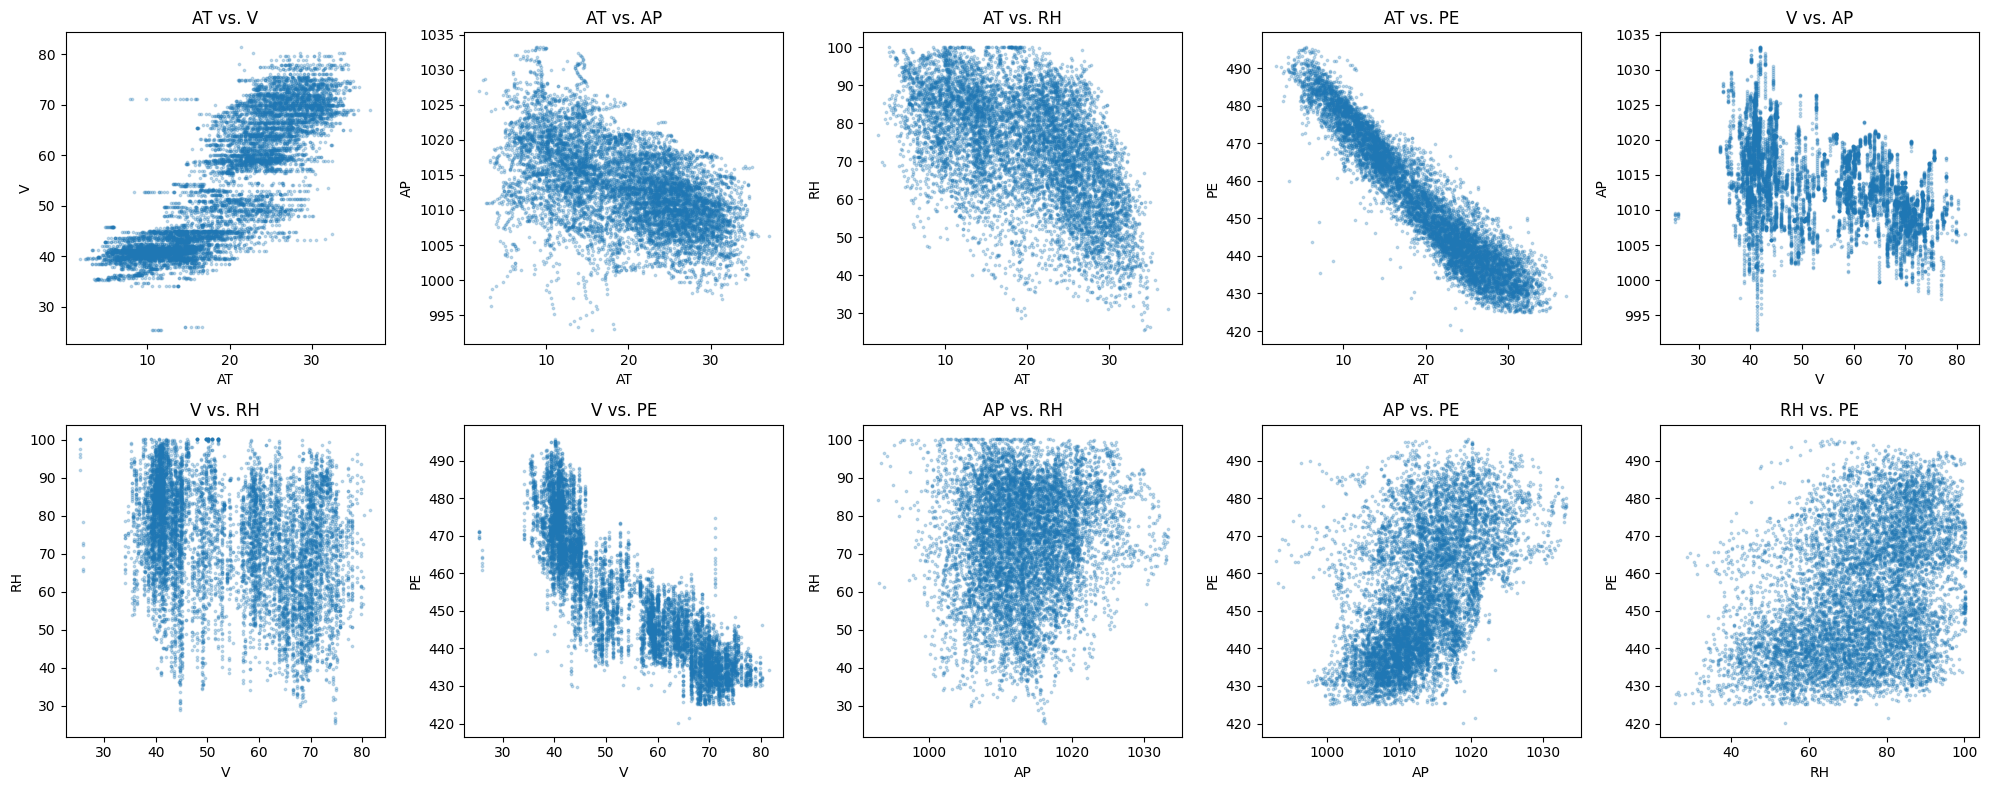

In [5]:
columns = list(df.columns)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

plot_num = 0

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        ax = axes.flat[plot_num]
        ax.scatter(df[columns[i]], df[columns[j]], s=3, alpha=0.25)
        ax.set_title(f'{columns[i]} vs. {columns[j]}')
        ax.set_xlabel(columns[i])
        ax.set_ylabel(columns[j])
        plot_num += 1

plt.tight_layout()
plt.show()

**Describe your findings**. The pairwise scatterplots show a few clear relationships among the variables. `AT` and `V` have relatively strong negative relationships with `PE`, while `AP` and `RH` have weaker positive relationships with `PE`. There are also noticeable relationships among some of the predictors, particularly between `AT` and `V`. Overall, the relationships appear mostly linear, although some plots show substantial variability (`V` vs. `RH`, `AP` vs. `RH`, and `V` vs. `AP`).

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [6]:
summary = df.describe()
summary = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Range': df.max() - df.min(),
    'First Quartile': df.quantile(0.25),
    'Third Quartile': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25)
})
summary

,Mean,Median,Range,First Quartile,Third Quartile,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

#### `AT` vs. `PE`

In [7]:
X_AT = df[['AT']]
y = df['PE']
X_AT = sm.add_constant(X_AT)
model_AT = sm.OLS(y, X_AT).fit()
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

##### Analysis: `AT` vs. `PE`
* In the model where `AT` is the predictor for `PE`, the **coefficient** for `AT` is -2.1713, meaning that for every 1°C increase in ambient temperature (`AT`), the predicted net hourly electrical energy output (`PE`) decreases by approximately 2.1713 MW.
* The **p-value** for `AT` is < 0.001, indicating that there is a statistically significant association between `AT` and `PE`.
* Additionally, the **R-squared value** for this model is .899, which indicates that 89.9% of the variation in `PE` is explained by `AT` in this simple linear regression model.

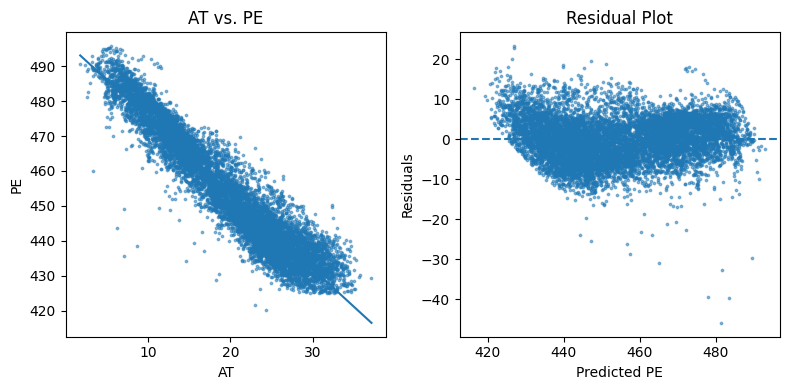

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Scatter plot
axes[0].scatter(df['AT'], df['PE'], s=3, alpha=0.5)

x_line = pd.DataFrame({'AT': [df['AT'].min(), df['AT'].max()]})
x_line = sm.add_constant(x_line)

axes[0].plot(x_line['AT'], model_AT.predict(x_line))

axes[0].set_xlabel('AT')
axes[0].set_ylabel('PE')
axes[0].set_title('AT vs. PE')

# Residual plot
axes[1].scatter(model_AT.fittedvalues, model_AT.resid, s=3, alpha=0.5)

axes[1].axhline(y=0, linestyle='--')

axes[1].set_xlabel('Predicted PE')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

##### Outliers: `AT` vs. `PE`
An outlier is an observation whose response value is unusually far from the value predicted by the model. If we take a look at the residual plot for `AT` vs. `PE`, we're looking for points that are unusually far from 0. There are many data points that are potential outliers in this plot, especially at predicted `PE` values of 440+, where some residuals are as low as -20 and going further below at -40 (whereas most residuals are between 10 and -10). Looking at the scatterplot also shows observations with large vertical distances from the regression line, which is consistent with the unusually large residuals shown in the residual plot. In the case of `AT` vs. `PE`, I would consider removing these potential outliers and refitting the model to determine whether they are having a substantial effect on the regression results.

In [9]:
X_V = df[['V']]
y = df['PE']
X_V = sm.add_constant(X_V)
model_V = sm.OLS(y, X_V).fit()
print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

#### Analysis: `V` vs. `PE`
* In the model where `V` is the predictor for `PE`, the **coefficient** for `V` is -1.1681, meaning that for every one-unit increase in exhaust vacuum `V`, the predicted net hourly electrical energy output (`PE`) decreases by 1.1681 MW.
* The **p-value** for `V` is < 0.001, indicating that there is a statistically significant association between `V` and `PE`.
* Additionally, the **R-squared value** for this model is .757, which indicates that 75.7% of the variation in `PE` is explained by `V` in this simple linear regression model.

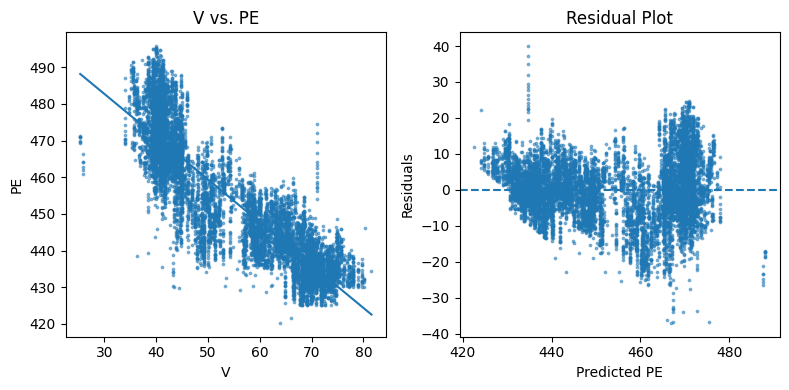

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Scatter plot
axes[0].scatter(df['V'], df['PE'], s=3, alpha=0.5)

x_line = pd.DataFrame({'V': [df['V'].min(), df['V'].max()]})
x_line = sm.add_constant(x_line)

axes[0].plot(x_line['V'], model_V.predict(x_line))

axes[0].set_xlabel('V')
axes[0].set_ylabel('PE')
axes[0].set_title('V vs. PE')

# Residual plot
axes[1].scatter(model_V.fittedvalues, model_V.resid, s=3, alpha=0.5)

axes[1].axhline(y=0, linestyle='--')

axes[1].set_xlabel('Predicted PE')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

##### Outliers: `V` vs. `PE`
An outlier is an observation whose response value is unusually far from the value predicted by the model. If we take a look at the residual plot for `V` vs. `PE`, we're looking for points that are unusually far from 0. There are several data points that are potential outliers in this plot, including residuals approaching 40 and -40, whereas most observations are considerably closer to 0. Looking at the scatterplot also shows some observations with large vertical distances from the regression line, which is consistent with the unusually large residuals shown in the residual plot. In the case of `V` vs. `PE`, I would consider removing these potential outliers and refitting the model to determine whether they are having a substantial effect on the regression results.

#### `AP` vs. `PE`

In [11]:
X_AP = df[['AP']]
y = df['PE']
X_AP = sm.add_constant(X_AP)
model_AP = sm.OLS(y, X_AP).fit()
print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

#### Analysis: `AP` vs. `PE`
* In the model where `AP` is the predictor for `PE`, the **coefficient** for `AP` is 1.4899, meaning that for every one-unit increase in ambient pressure (`AP`), the predicted net hourly electrical energy output (`PE`) increases by 1.4899 MW.
* The **p-value** for `AP` is < 0.001, indicating that there is a statistically significant association between `AP` and `PE`.
* Additionally, the **R-squared value** for this model is .269, which indicates that 26.9% of the variation in `PE` is explained by `AP` in this simple linear regression model.

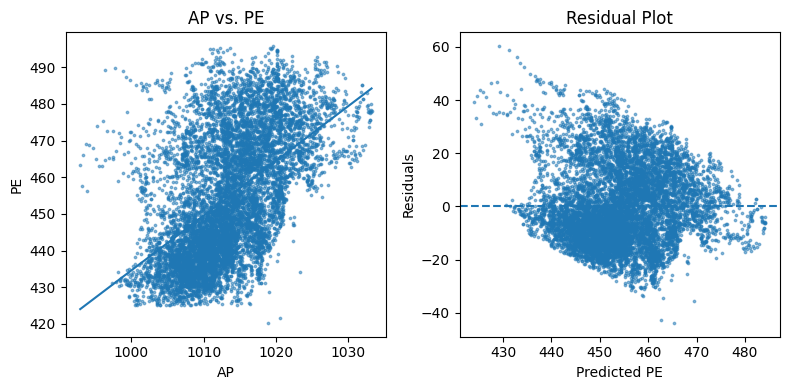

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Scatter plot
axes[0].scatter(df['AP'], df['PE'], s=3, alpha=0.5)

x_line = pd.DataFrame({'AP': [df['AP'].min(), df['AP'].max()]})
x_line = sm.add_constant(x_line)

axes[0].plot(x_line['AP'], model_AP.predict(x_line))

axes[0].set_xlabel('AP')
axes[0].set_ylabel('PE')
axes[0].set_title('AP vs. PE')

# Residual plot
axes[1].scatter(model_AP.fittedvalues, model_AP.resid, s=3, alpha=0.5)

axes[1].axhline(y=0, linestyle='--')

axes[1].set_xlabel('Predicted PE')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

##### Outliers: `AP` vs. `PE`
Although there is some variation in the residuals, there are no particular observations that appear sufficiently isolated from the majority of the data to justify removing them as outliers.

#### `RH` vs. `PE`

In [13]:
X_RH = df[['RH']]
y = df['PE']
X_RH = sm.add_constant(X_RH)
model_RH = sm.OLS(y, X_RH).fit()
print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

#### Analysis: `RH` vs. `PE`
* In the model where `RH` is the predictor for `PE`, the **coefficient** for `RH` is .4557, meaning that for every one-unit increase in relative humidity (`RH`), the predicted net hourly electrical energy output (`PE`) increases by .4557 MW.
* The **p-value** for `RH` is < 0.001, indicating that there is a statistically significant association between `RH` and `PE`.
* Additionally, the **R-squared value** for this model is .152, which indicates that 15.2% of the variation in `PE` is explained by `RH` in this simple linear regression model.

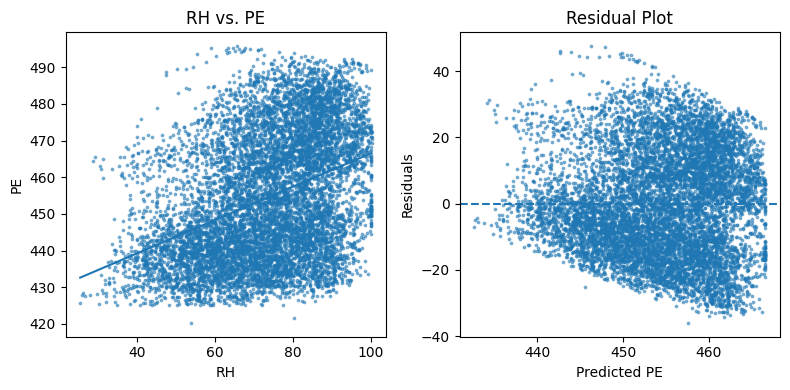

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Scatter plot
axes[0].scatter(df['RH'], df['PE'], s=3, alpha=0.5)

x_line = pd.DataFrame({'RH': [df['RH'].min(), df['RH'].max()]})
x_line = sm.add_constant(x_line)

axes[0].plot(x_line['RH'], model_RH.predict(x_line))

axes[0].set_xlabel('RH')
axes[0].set_ylabel('PE')
axes[0].set_title('RH vs. PE')

# Residual plot
axes[1].scatter(model_RH.fittedvalues, model_RH.resid, s=3, alpha=0.5)

axes[1].axhline(y=0, linestyle='--')

axes[1].set_xlabel('Predicted PE')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

##### Outliers: `RH` vs. `PE`
Although there is some variation in the residuals, there are no particular observations that appear sufficiently isolated from the majority of the data to justify removing them as outliers.

### (d) Multiple Regression

In [15]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']
X = sm.add_constant(X)
model_multiple = sm.OLS(y, X).fit()
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

#### Analysis: Multiple Regression

In our multiple regression model, we included all 4 of our predictors, `AT`, `V`, `AP` and `RH` to predict `PE`. This model achieved an **R-squared of .929**, indicating that 92.9% of the variation in `PE` is accounted by this model. Because this R-squared is higher than that of any of our previous models, this tells us that the multiple regression model performs better than any of our previous models using each predictor alone to predict `PE`. Since the p-values for all coefficients (β₁, β₂, β₃, β₄) are each < .001, we determine that each coefficient is statistically significant, and thereby reject the null hypothesis that H₀ : βj = 0.

* **β₁**, the coefficient for `AT`, is -1.9775. This means that for every 1°C increase in ambient temperature, the plant's net hourly electrical energy output is expected to decrease by approximately 1.9775 MW, assuming exhaust vacuum, ambient pressure, and relative humidity remain constant.

* **β₂**, the coefficient for `V`, is -.2339. This means that as exhaust vacuum increases by one unit, the plant's net hourly electrical energy output is expected to decrease by approximately .2339 MW, assuming ambient temperature, ambient pressure, and relative humidity remain constant.

* **β₃**, the coefficient for `AP`, is .0621. This means that as ambient pressure increases by one unit, the plant's net hourly electrical energy output is expected to increase by approximately .0621 MW, assuming ambient temperature, exhaust vacuum, and relative humidity remain constant.

* **β₄**, the coefficient for `RH`, is -.1581. This means that as relative humidity increases by one percentage point, the plant's net hourly electrical energy output is expected to decrease by approximately .1581 MW, assuming ambient temperature, exhaust vacuum, and ambient pressure remain constant.

### (e) 1c Compare to 1d

In [16]:
coef_plot = pd.DataFrame({
    'Predictor': ['AT', 'V', 'AP', 'RH'],
    'Simple': [
        model_AT.params['AT'],
        model_V.params['V'],
        model_AP.params['AP'],
        model_RH.params['RH']
    ],
    'Multiple': [
        model_multiple.params['AT'],
        model_multiple.params['V'],
        model_multiple.params['AP'],
        model_multiple.params['RH']
    ]
})

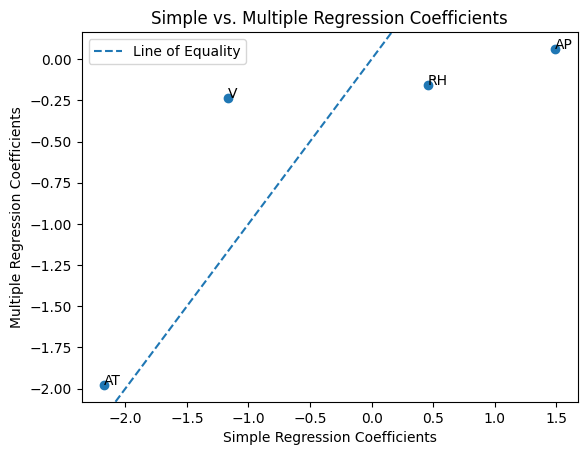

In [17]:
x_coef_plot = coef_plot['Simple']
y_coef_plot = coef_plot['Multiple']
fig, ax = plt.subplots()
ax.scatter(x_coef_plot, y_coef_plot)

for i in range(len(coef_plot)):
    ax.annotate(
        coef_plot['Predictor'][i],
        (x_coef_plot[i], y_coef_plot[i])
    )
    
ax.axline((0, 0), slope=1, linestyle='--', label='Line of Equality')
ax.legend()
ax.set_xlabel('Simple Regression Coefficients')
ax.set_ylabel('Multiple Regression Coefficients')
ax.set_title('Simple vs. Multiple Regression Coefficients')

plt.show()

#### Coefficient analysis: simple regression vs. multiple regression
**How do my results compare from 1c to my results from 1d?** According to the coefficient plot comparing the coefficient values for simple regression compared to multiple regression, we can see that the coefficients, for each predictor, are not equivalent to each other in the simple model vs. the multiple regression model. Additionally, a point on the line of equality would indicate that the coefficient for the simple regression is equal to the coefficient for the multiple regression; the further away it is from this line, the greater the difference between the models' coefficient values.  

Based on the plot:
* `AT` has relatively similar coefficient estimates in the simple and multiple regression models.
* `V` shows a substantial difference between its simple and multiple regression coefficient estimates.
* `RH` shows a substantial difference and changes from a positive coefficient in the simple regression to a negative coefficient in the multiple regression.
* `AP` shows a substantial difference, with its coefficient becoming much smaller in the multiple regression model.

### (f) Nonlinear Association

In [18]:
X_AT_poly = pd.DataFrame({
    'AT': df['AT'],
    'AT^2': df['AT'] ** 2,
    'AT^3': df['AT'] ** 3
})

X_AT_poly = sm.add_constant(X_AT_poly)

model_AT_poly = sm.OLS(y, X_AT_poly).fit()

print(model_AT_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

**`AT` polynomial analysis**: The coefficients for `AT`, `AT^2` and `AT^3` are all statistically significant, indicating that there is indeed evidence of nonlinear association between `AT` and `PE`.

In [19]:
X_V_poly = pd.DataFrame({
    'V': df['V'],
    'V^2': df['V'] ** 2,
    'V^3': df['V'] ** 3
})

X_V_poly = sm.add_constant(X_V_poly)

model_V_poly = sm.OLS(y, X_V_poly).fit()

print(model_V_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

**`V` polynomial analysis**: The coefficients for `V` and `V^3` are statistically significant, indicating that there is indeed evidence of nonlinear association between `V` and `PE`. However, the p-value for `V^2` is .768, indicating that this coefficient is not statistically significant; therefore, we fail to reject the hypothesis that the coefficient for `V^2` is equal to 0.

In [20]:
X_AP_poly = pd.DataFrame({
    'AP': df['AP'],
    'AP^2': df['AP'] ** 2,
    'AP^3': df['AP'] ** 3
})

X_AP_poly = sm.add_constant(X_AP_poly)

model_AP_poly = sm.OLS(y, X_AP_poly).fit()

print(model_AP_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0747      0.009      8.415      0.0

/var/folders/jm/cckh5tcj3fv8rh18bl85ggmc0000gn/T/ipykernel_13031/2654475941.py:9: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_AP_poly = sm.OLS(y, X_AP_poly).fit()


**`AP` polynomial analysis**: The coefficients for `AP`, `AP^2` and `AP^3` are all statistically significant, indicating that there is indeed evidence of nonlinear association between `AP` and `PE`.

In [21]:
X_RH_poly = pd.DataFrame({
    'RH': df['RH'],
    'RH^2': df['RH'] ** 2,
    'RH^3': df['RH'] ** 3
})

X_RH_poly = sm.add_constant(X_RH_poly)

model_RH_poly = sm.OLS(y, X_RH_poly).fit()

print(model_RH_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        468.4135     10.545     44.422      0.0

**`RH` polynomial analysis**: The coefficients for `RH`, `RH^2` and `RH^3` are all statistically significant, indicating that there is indeed evidence of nonlinear association between `RH` and `PE`.

### (g) Interactions of Predictors

In [22]:
X = df[['AT', 'V', 'AP', 'RH']]

X['AT_V'] = df['AT'] * df['V']
X['AT_AP'] = df['AT'] * df['AP']
X['AT_RH'] = df['AT'] * df['RH']
X['V_AP'] = df['V'] * df['AP']
X['V_RH'] = df['V'] * df['RH']
X['AP_RH'] = df['AP'] * df['RH']

y = df['PE']

X = sm.add_constant(X)

model_interactions = sm.OLS(y, X).fit()

print(model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

Yes, there is evidence of association of interactions of predictors with the response. In this full linear regression model with all pairwise interaction terms, we found that the following **interaction terms** are statistically significant: 

* AT x V, with a p-value < .001
* AT x RH, with a p-value < .001
* V x AP, with a p-value < .001
* AP x RH, with a p-value = .034

Because of this, we reject the null hypothesis that the coefficients for these interaction terms are equal to zero, providing evidence that these pairs of predictors interact in their association with `PE`.  

The remaining interaction terms, `AT × AP` and `V × RH`, are not statistically significant.

### (h) Improvement

In [23]:
# Train the regression model on a randomly selected 70% subset of the data with all predictors.
train, test = train_test_split(df, test_size=.3, random_state=73)

X_train = train[['AT', 'V', 'AP', 'RH']]
y_train = train['PE']

X_test = test[['AT', 'V', 'AP', 'RH']]
y_test = test['PE']

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model_train = sm.OLS(y_train, X_train).fit()
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 2.225e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -19593.
No. Observations:                6697   AIC:                         3.920e+04
Df Residuals:                    6692   BIC:                         3.923e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        458.8924     11.483     39.963      0.0

In [24]:
# Run a regression model involving all possible interaction terms and quadratic nonlinearities, and remove insignificant variables using p-values

X_train_improved = pd.DataFrame({
    'AT': train['AT'],
    'V': train['V'],
    'AP': train['AP'],
    'RH': train['RH'],

    'AT^2': train['AT'] ** 2,
    'V^2': train['V'] ** 2,
    'AP^2': train['AP'] ** 2,
    'RH^2': train['RH'] ** 2,

    'AT_V': train['AT'] * train['V'],
    'AT_AP': train['AT'] * train['AP'],
    'AT_RH': train['AT'] * train['RH'],
    'V_AP': train['V'] * train['AP'],
    'V_RH': train['V'] * train['RH'],
    'AP_RH': train['AP'] * train['RH']
})

X_train_improved = sm.add_constant(X_train_improved)
model_improved = sm.OLS(y_train, X_train_improved).fit()
print(model_improved.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     7387.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -19118.
No. Observations:                6697   AIC:                         3.827e+04
Df Residuals:                    6682   BIC:                         3.837e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7195.5474   1413.849     -5.089      0.0

In [25]:
# Remove insignificant variables using p-values from the improved model

X_train_improved = pd.DataFrame({
    'AT': train['AT'],
    'V': train['V'],
    'AP': train['AP'],
    'RH': train['RH'],

    'AT^2': train['AT'] ** 2,
    'AP^2': train['AP'] ** 2,
    'RH^2': train['RH'] ** 2,

    'AT_V': train['AT'] * train['V'],
    'AT_RH': train['AT'] * train['RH'],
    'AP_RH': train['AP'] * train['RH']
})

X_train_improved = sm.add_constant(X_train_improved)
model_improved = sm.OLS(y_train, X_train_improved).fit()
print(model_improved.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                 1.032e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:28:24   Log-Likelihood:                -19126.
No. Observations:                6697   AIC:                         3.827e+04
Df Residuals:                    6686   BIC:                         3.835e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.015e+04   1069.955     -9.486      0.0

In [26]:
train_predictions = model_train.predict(X_train)
test_predictions = model_train.predict(X_test)

train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

print('Multiple Linear Regression - Train MSE:', f"{train_mse:.4f}")
print('Multiple Linear Regression - Test MSE:', f"{test_mse:.4f}")

Multiple Linear Regression - Train MSE: 20.3549
Multiple Linear Regression - Test MSE: 21.7499


In [27]:
X_test_improved = pd.DataFrame({
    'AT': test['AT'],
    'V': test['V'],
    'AP': test['AP'],
    'RH': test['RH'],

    'AT^2': test['AT'] ** 2,
    'AP^2': test['AP'] ** 2,
    'RH^2': test['RH'] ** 2,

    'AT_V': test['AT'] * test['V'],
    'AT_RH': test['AT'] * test['RH'],
    'AP_RH': test['AP'] * test['RH']
})

X_test_improved = sm.add_constant(X_test_improved)
train_predictions = model_improved.predict(X_train_improved)
test_predictions = model_improved.predict(X_test_improved)

improved_train_mse = mean_squared_error(y_train, train_predictions)
improved_test_mse = mean_squared_error(y_test, test_predictions)

print('Improved Regression Model - Train MSE:', f"{improved_train_mse:.4f}")
print('Improved Regression Model - Test MSE:', f"{improved_test_mse:.4f}")

Improved Regression Model - Train MSE: 17.7068
Improved Regression Model - Test MSE: 19.1782


**Can you improve your model using possible interaction terms or nonlinear associations between the predictors and response?** The improved regression model (`model_improved`) achieved a lower training MSE (17.7068 vs. 20.3549) and a lower test MSE (19.1782 vs. 21.7499) than the multiple linear regression model. Therefore, including the statistically significant interaction and quadratic terms improved the model's performance on both the training and test data.

### (i) KNN

In [28]:
X_train_knn = train[['AT', 'V', 'AP', 'RH']]
X_test_knn = test[['AT', 'V', 'AP', 'RH']]

#### KNN regression using normalized features

In [29]:
train_errors_normalized = []
test_errors_normalized = []
k_values = list(range(1,101))

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train_knn)
X_test_normalized = scaler.transform(X_test_knn)

for k in k_values:

    # Create and fit the KNN regressor
    knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_normalized, y_train)

    # Predict the training and test values
    y_train_pred = knn.predict(X_train_normalized)
    y_test_pred = knn.predict(X_test_normalized)

    # Calculate the training and test MSE
    train_error_normalized = mean_squared_error(y_train, y_train_pred)
    test_error_normalized = mean_squared_error(y_test, y_test_pred)

    # Store errors for each value of k
    train_errors_normalized.append(train_error_normalized)
    test_errors_normalized.append(test_error_normalized)

k_star_normalized = k_values[
    test_errors_normalized.index(min(test_errors_normalized))
]

print('The value of k that gives the best fit in the dataset using its normalized features is', k_star_normalized)

The value of k that gives the best fit in the dataset using its normalized features is 4


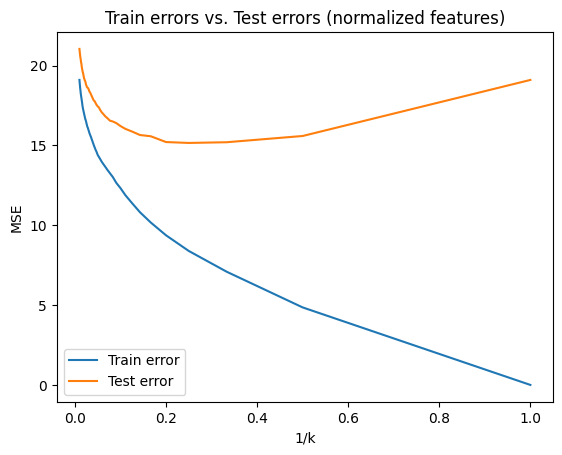

In [30]:
k_inverse = [1/k for k in k_values]

plt.plot(k_inverse, train_errors_normalized, label='Train error')
plt.plot(k_inverse, test_errors_normalized, label='Test error')
plt.title('Train errors vs. Test errors (normalized features)')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.legend()

plt.show()

#### KNN regression using raw features

In [31]:
train_errors_raw = []
test_errors_raw = []
k_values = list(range(1,101))

for k in k_values:

    # Create and fit the KNN regressor
    knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_knn, y_train)

    # Predict the training and test values
    y_train_pred = knn.predict(X_train_knn)
    y_test_pred = knn.predict(X_test_knn)

    # Calculate the training and test MSE
    train_error_raw = mean_squared_error(y_train, y_train_pred)
    test_error_raw = mean_squared_error(y_test, y_test_pred)

    # Store errors for each value of k
    train_errors_raw.append(train_error_raw)
    test_errors_raw.append(test_error_raw)

k_star_raw = k_values[test_errors_raw.index(min(test_errors_raw))]

print('The value of k that gives the best fit in the dataset using its raw features is', k_star_raw)

The value of k that gives the best fit in the dataset using its raw features is 5


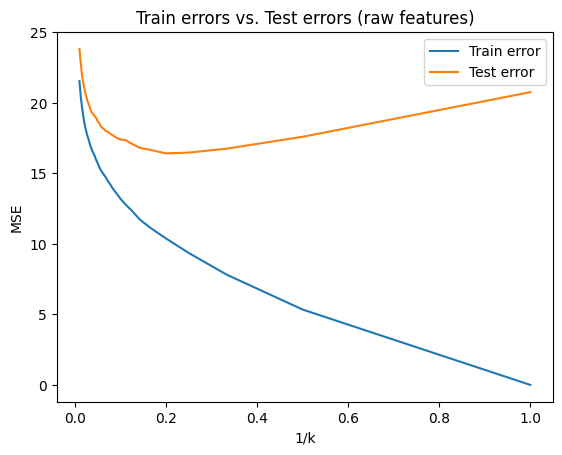

In [32]:
k_inverse = [1/k for k in k_values]

plt.plot(k_inverse, train_errors_raw, label='Train error')
plt.plot(k_inverse, test_errors_raw, label='Test error')
plt.title('Train errors vs. Test errors (raw features)')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.legend()

plt.show()

### (j) Compare KNN and Linear

In [33]:
print('Improved Regression Model Test MSE:', f"{improved_test_mse:.4f}")
print('Best Raw KNN Test MSE:', f"{min(test_errors_raw):.4f}")
print('Best Normalized KNN Test MSE:', f"{min(test_errors_normalized):.4f}")

Improved Regression Model Test MSE: 19.1782
Best Raw KNN Test MSE: 16.4159
Best Normalized KNN Test MSE: 15.1571


#### Analysis: KNN regression vs. linear regression
The KNN regression models performed better than the improved linear regression model: on raw features, KNN regression achieved a test MSE of 16.4159 at `k*=5`, and on normalized features, KNN regression achieved a test MSE of 15.1571 at `k*=4`, compared to the test MSE of the linear regression model, which achieved a 19.1782 MSE. Thus, KNN regression performed better than the linear regression model on the test data, with normalized KNN achieving the best performance of all.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

When the sample size `n` is extremely large and the number of predictors `p` is small, we have many observations compared to the number of predictors, indicating that there would be less concern about variance and overfitting from flexibility. Thus, in this case, a flexible method would generally perform better.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

When the sample size `n` is small and the number of predictors `p` is extremely large, we have a small amount of observations compared to the number of predictors, so there would be more concern about variance and overfitting from flexibility. If a method has high variance, then small changes in the training data can result in large changes in the predicted value. Thus, in this case, a flexible method would generally perform worse than an inflexible model.

### (c) The relationship between the predictors and response is highly non-linear.

If the relationship between predictors and response is highly non-linear, then no matter how many training observations we are given, it will still not be possible to produce an accurate estimate using a simple model (such as linear regression). This is due to bias, which refers to the error that is introduced by approximating a real-life problem (that may actually be complicated) by a much simpler model. If the true $f$ is not close to linear at all, a simple model such as linear regression will not be able to produce an accurate estimate $\hat{f}$, resulting in high bias. Thus, in this case, a flexible method would generally perform better than an inflexible method because it can reduce bias and better capture the non-linear relationship.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Variance refers to the amount by which $\hat{f}$ would change if we estimated it using a different training data set. If a method has high variance, then small changes in the training data can result in large changes in $\hat{f}$. Since the variance of the error terms is extremely high, there is already a large amount of irreducible error in the data. In this case, we would expect less flexible methods to perform better, because these methods would result in lower variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

Euclidean distance, $d = \sqrt{(X_1-X_{1,0})^2+(X_2-X_{2,0})^2+(X_3-X_{3,0})^2}$  

Observation 1: $d = \sqrt{(0-0)^2+(3-0)^2+(0-0)^2} = \sqrt{9} = 3$  
Observation 2: $d = \sqrt{(2-0)^2+(0-0)^2+(0-0)^2} = \sqrt{4} = 2$  
Observation 3: $d = \sqrt{(0-0)^2+(1-0)^2+(3-0)^2} = \sqrt{10}$  
Observation 4: $d = \sqrt{(0-0)^2+(1-0)^2+(2-0)^2} = \sqrt{5}$  
Observation 5: $d = \sqrt{(-1-0)^2+(0-0)^2+(1-0)^2} = \sqrt{2}$  
Observation 6: $d = \sqrt{(1-0)^2+(1-0)^2+(1-0)^2} = \sqrt{3}$

### (b) What is our prediction with K = 1? Why?

With `K=1`, we consider only the single observation with the smallest distance. The smallest distance is $\sqrt{2}$, which corresponds to Observation 5, whose response is Green. Thus, we predict that `Y` will be Green.

### (c) What is our prediction with K = 3? Why?

With `K=3`, we consider the three observations with the smallest distances across the dataset. The three smallest distances are $\sqrt{2}$ (corresponding with Observation 5), $\sqrt{3}$ (corresponding with Observation 6) and $2$ (corresponding with Observation 2). Respectively, `Y` was Green, Red and Red across these three observations. Due to majority voting, with `K=3`, we predict that `Y` will be Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

The Bayes decision boundary classifies what `Y` will be based on whichever class is more probable. If this decision boundary is highly non-linear, then we would expect the best value for K to be smaller rather than larger, because we use fewer neighbors to classify `Y`, which makes the KNN classifier more flexible, allowing it to better capture a highly non-linear decision boundary.